# 24 - Competitiveness, Skill Rarity, and Sensitivity Analysis

This notebook extends the Chapter 3 positioning framework by quantifying **how difficult it is for a user to access each job**, rather than how suitable the job is. Competitiveness is defined as a *barrier-to-entry metric* that combines (i) the expected number of required skills the user is missing—estimated probabilistically using the skill probability matrix—and (ii) the relative salary level of the job within the candidate set. Skill rarity is incorporated by upweighting missing skills that are globally uncommon across the job landscape, ensuring that gaps in rare, high-value skills contribute more strongly to the competitiveness score than gaps in ubiquitous skills.

In addition, the notebook performs **sensitivity analyses** for both suitability and competitiveness. These analyses systematically vary the component weights (skill vs salary) and quantify ranking stability using Spearman rank correlations against a baseline configuration. This provides an explicit robustness check, demonstrating whether the job rankings are stable to reasonable modelling assumptions, and identifying regimes where rankings become weight-sensitive. Together, these steps complete the diagnostic layer of Chapter 3, separating *job desirability* (suitability) from *access difficulty* (competitiveness) and validating both through controlled sensitivity testing.


## Set Up

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#===
import sys
from pathlib import Path

### Paths

In [2]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [3]:
from src.job_intel.positioning import run_positioning
from src.job_intel.features.artefacts_ch3 import load_ch3_artefacts

## Competitiviness index

In [6]:
# -------------------------------------------------------
# 0) Run positioning to obtain candidates
# -------------------------------------------------------

profile, candidates_df, gap_df, _ = run_positioning(
    skill_text=(
        "Python, SQL, machine learning, statistics, data analysis, "
        "scikit-learn, pandas, experimentation"
    ),
    current_state="CA",
    job_title_family="data_scientist",
    salary_target=150000,
    return_top_n_jobs=50,
)

# Load artefacts
_, skill_prob_matrix = load_ch3_artefacts()


# -------------------------------------------------------
# 1) User missing-skill vector (1 = missing)
# -------------------------------------------------------

user_vec = profile["derived"]["skill_vector"].iloc[0].to_numpy()   # shape (27,)
missing_vec = 1 - user_vec


# -------------------------------------------------------
# 2) Align skill probability matrix to candidate jobs
# -------------------------------------------------------

skill_cols = profile["derived"]["skill_vector"].columns.tolist()
prob_cols = [f"{s}_prob" for s in skill_cols]

probs = (
    skill_prob_matrix.loc[
        skill_prob_matrix["job_id"].isin(candidates_df["job_id"]),
        ["job_id"] + prob_cols,
    ]
    .set_index("job_id")
    .loc[candidates_df["job_id"]]   # enforce identical ordering
)


# -------------------------------------------------------
# 3) Skill rarity (market-level)
# -------------------------------------------------------

# Mean probability of each skill across all jobs
skill_prevalence = skill_prob_matrix[prob_cols].mean(axis=0).to_numpy()

# Inverse frequency → rarity
rarity_vec = 1 - skill_prevalence


# -------------------------------------------------------
# 4) Expected missing skill rarity per job
# -------------------------------------------------------

expected_missing_rarity = probs.to_numpy() @ (missing_vec * rarity_vec)

candidates_df = candidates_df.copy()
candidates_df["expected_missing_rarity"] = expected_missing_rarity

# Normalise to [0, 1]
candidates_df["expected_missing_rarity_norm"] = (
    candidates_df["expected_missing_rarity"] / np.sum(rarity_vec)
)


# -------------------------------------------------------
# 5) Salary percentile barrier
# -------------------------------------------------------

candidates_df["salary_pct"] = candidates_df["sal_mean"].rank(
    pct=True, method="average"
)


# -------------------------------------------------------
# 6) Final competitiveness index
# -------------------------------------------------------

w_skill = 0.7
w_salary = 0.3

candidates_df["competitiveness_index"] = (
    w_salary * candidates_df["salary_pct"]
    + w_skill * (1 - candidates_df["expected_missing_rarity_norm"])
)


In [7]:
candidates_df["competitiveness_index"]

3025    0.867163
2870    0.816578
3033    0.915824
3130    0.747535
382     0.722117
3112    0.791706
2873    0.856217
2883    0.796633
2881    0.844336
3141    0.706627
3015    0.886676
528     0.835906
3193    0.728999
3035    0.934508
3041    0.701896
3048    0.780546
3073    0.804797
3029    0.869701
3090    0.784986
3068    0.603192
532     0.729333
357     0.629945
2866    0.887780
2963    0.843823
2994    0.926555
2993    0.920573
3153    0.752517
372     0.585192
2887    0.814884
2878    0.728159
366     0.717323
345     0.640879
340     0.614676
3164    0.840034
2136    0.665464
3086    0.773345
2991    0.868705
2998    0.860429
341     0.565381
2903    0.716009
533     0.876255
332     0.704932
2876    0.727414
2864    0.845826
5834    0.687771
2146    0.685351
2841    0.624607
3127    0.731806
2894    0.753426
3103    0.731457
Name: competitiveness_index, dtype: float64

In [8]:
candidates_df[["sal_mean", "salary_pct"]].describe()
candidates_df.sort_values("salary_pct", ascending=False)[["title_rich", "sal_mean", "salary_pct"]].head(5)


,title_rich,sal_mean,salary_pct
2993,general_data_data_scientist,225000.0,0.97
2998,general_data_data_scientist,225000.0,0.97
2991,general_data_data_scientist,225000.0,0.97
2994,ML_AI_data_scientist,225000.0,0.97
2963,ML_AI_data_scientist,193500.0,0.92


## Skill Rarity Integration

In [9]:
# --- Build global rarity weights (already mostly done) ---
global_skill_p_mean = (
    skill_prob_matrix
    .drop(columns=["job_id"])
    .mean(axis=0)
    .rename("global_average")
    .reset_index()
    .rename(columns={"index": "prob_col"})
)

eps = 1e-5
global_skill_p_mean["rarity_weight"] = 1 / (global_skill_p_mean["global_average"] + eps)

# Convert "skillname_prob" -> "skillname" (canonical key)
global_skill_p_mean["skill"] = global_skill_p_mean["prob_col"].str.replace("_prob", "", regex=False)

# Mean-normalise (stable scale)
global_skill_p_mean["weight_norm"] = global_skill_p_mean["rarity_weight"] / global_skill_p_mean["rarity_weight"].mean()

# --- Align weights to the user skill column order (critical) ---
skill_cols = profile["derived"]["skill_vector"].columns.tolist()

w_lookup = (
    global_skill_p_mean
    .set_index("skill")["weight_norm"]
    .reindex(skill_cols)
)

assert w_lookup.isna().sum() == 0, "Rarity weights missing for some skills (alignment failure)."

w_vec = w_lookup.to_numpy()  # length 27, aligned to skill_cols

# --- Apply rarity to missingness (vectorised) ---
prob_cols = [f"{s}_prob" for s in skill_cols]

probs = (
    skill_prob_matrix.loc[
        skill_prob_matrix["job_id"].isin(candidates_df["job_id"]),
        ["job_id"] + prob_cols,
    ]
    .set_index("job_id")
    .loc[candidates_df["job_id"]]
)

user_vec = profile["derived"]["skill_vector"].iloc[0].to_numpy()
missing_vec = 1 - user_vec

# rarity-weighted missing burden (sum across skills)
expected_missing_rarity = (probs.to_numpy() * w_vec) @ missing_vec

# normalise to ~0–1 scale (mean-normalised weights => divide by n_skills)
expected_missing_rarity_norm = expected_missing_rarity / len(skill_cols)

candidates_df = candidates_df.copy()
candidates_df["expected_missing_rarity"] = expected_missing_rarity
candidates_df["expected_missing_rarity_norm"] = expected_missing_rarity_norm.clip(0, 1)

# quick sanity
global_skill_p_mean.sort_values("weight_norm", ascending=False)[["skill","global_average","weight_norm"]]


,skill,global_average,weight_norm
2,core_programming__advanced,0.002108,11.289112
23,productivity_workflow__advanced,0.002775,8.584805
14,bi_viz__advanced,0.017947,1.331542
11,analytics_stats__advanced,0.019657,1.215762
20,db_storage__advanced,0.025986,0.919763
17,cloud__advanced,0.027831,0.858805
3,data_engineering_pipelines__basic,0.035023,0.682515
8,ml_ai__advanced,0.093998,0.254344
16,cloud__intermediate,0.104146,0.229562
1,core_programming__intermediate,0.113261,0.211089


In [10]:
probs

,core_programming__basic_prob,core_programming__intermediate_prob,core_programming__advanced_prob,data_engineering_pipelines__basic_prob,data_engineering_pipelines__intermediate_prob,data_engineering_pipelines__advanced_prob,ml_ai__basic_prob,ml_ai__intermediate_prob,ml_ai__advanced_prob,analytics_stats__basic_prob,...,cloud__advanced_prob,db_storage__basic_prob,db_storage__intermediate_prob,db_storage__advanced_prob,productivity_workflow__basic_prob,productivity_workflow__intermediate_prob,productivity_workflow__advanced_prob,soft_skills__core_prob,soft_skills__leadership_prob,domain_specific__none_prob
job_id,,,,,,,,,,,,,,,,,,,,,
3025,0.974415,0.125665,4.253767e-08,0.008181,0.108144,0.009040,0.127992,0.053543,0.007192,0.993427,...,0.000500,0.980505,0.004864,4.837030e-06,0.000112,0.003651,8.640852e-07,0.938844,0.069652,0.087717
2870,0.996545,0.985154,6.299818e-08,0.015961,0.044978,0.055537,0.050456,0.074790,0.003176,0.879284,...,0.000447,0.375188,0.153493,1.037603e-05,0.764536,0.077836,3.651568e-05,0.240183,0.048576,0.015773
3033,0.987171,0.137943,1.696303e-07,0.004801,0.065554,0.056897,0.930959,0.304461,0.010003,0.976128,...,0.002641,0.968721,0.049900,3.068626e-07,0.000967,0.004978,5.565309e-07,0.088746,0.553183,0.138136
3130,0.987609,0.040082,2.798335e-08,0.002870,0.016830,0.079980,0.933644,0.194482,0.002389,0.958982,...,0.000038,0.977137,0.007041,2.748451e-06,0.000111,0.000866,1.127830e-06,0.046166,0.056112,0.961883
382,0.991661,0.004419,1.547046e-08,0.001346,0.023168,0.035710,0.200076,0.924874,0.007264,0.953444,...,0.000116,0.951927,0.001633,1.095467e-05,0.000517,0.001299,2.895705e-07,0.951187,0.090160,0.036246
3112,0.998837,0.022119,4.350121e-08,0.002325,0.027255,0.111311,0.939449,0.945657,0.030101,0.993101,...,0.000551,0.601286,0.107876,1.565971e-06,0.000014,0.020129,1.546583e-06,0.986016,0.070206,0.011818
2873,0.888068,0.129765,6.701837e-09,0.002525,0.968711,0.006337,0.944155,0.069356,0.017947,0.056558,...,0.000084,0.948760,0.008303,2.623519e-06,0.000348,0.002729,2.939481e-07,0.057989,0.076092,0.061341
2883,0.993120,0.012309,2.687778e-05,0.004217,0.136103,0.908870,0.250517,0.970002,0.987458,0.541871,...,0.035229,0.752238,0.016747,2.829160e-05,0.000032,0.000366,2.439340e-07,0.047644,0.157477,0.010228
2881,0.999553,0.935920,2.495368e-06,0.015149,0.029080,0.058687,0.108081,0.037014,0.000620,0.940086,...,0.000315,0.884374,0.005879,4.483736e-06,0.000083,0.031453,7.243316e-06,0.803809,0.029250,0.019839


## Sensitivity

### Competitiveness

In [11]:
from scipy.stats import spearmanr


weight_grid = [
    {"w_skill": 0.1, "w_salary": 0.9},
    {"w_skill": 0.2, "w_salary": 0.8},
    {"w_skill": 0.3, "w_salary": 0.7},
    {"w_skill": 0.4, "w_salary": 0.6},
    {"w_skill": 0.5, "w_salary": 0.5},
    {"w_skill": 0.6, "w_salary": 0.4},
    {"w_skill": 0.7, "w_salary": 0.3},  # baseline
    {"w_skill": 0.8, "w_salary": 0.2},
    {"w_skill": 0.9, "w_salary": 0.1},
]


# 1) baseline ranks per job_id
base_score = candidates_df["competitiveness_index"]
base_rank = base_score.rank(ascending=False, method="average")
base_rank_by_job = pd.Series(base_rank.values, index=candidates_df["job_id"])

out = []

for w in weight_grid:
    tmp_score = (
        w["w_skill"] * candidates_df["expected_missing_rarity_norm"]
        + w["w_salary"] * candidates_df["salary_pct"]
    )

    tmp_rank = tmp_score.rank(ascending=False, method="average")
    tmp_rank_by_job = pd.Series(tmp_rank.values, index=candidates_df["job_id"])

    # align by job_id (critical)
    aligned = pd.concat([base_rank_by_job, tmp_rank_by_job], axis=1).dropna()
    rho, _ = spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])

    out.append({
        "w_skill": w["w_skill"],
        "w_salary": w["w_salary"],
        "spearman_rho_vs_baseline": rho,
    })

sensitivity = pd.DataFrame(out)


In [12]:
sensitivity

,w_skill,w_salary,spearman_rho_vs_baseline
0,0.1,0.9,0.839040
1,0.2,0.8,0.839040
2,0.3,0.7,0.839040
3,0.4,0.6,0.839040
4,0.5,0.5,0.839040
5,0.6,0.4,0.822809
6,0.7,0.3,0.813589
7,0.8,0.2,0.782089
8,0.9,0.1,0.626218


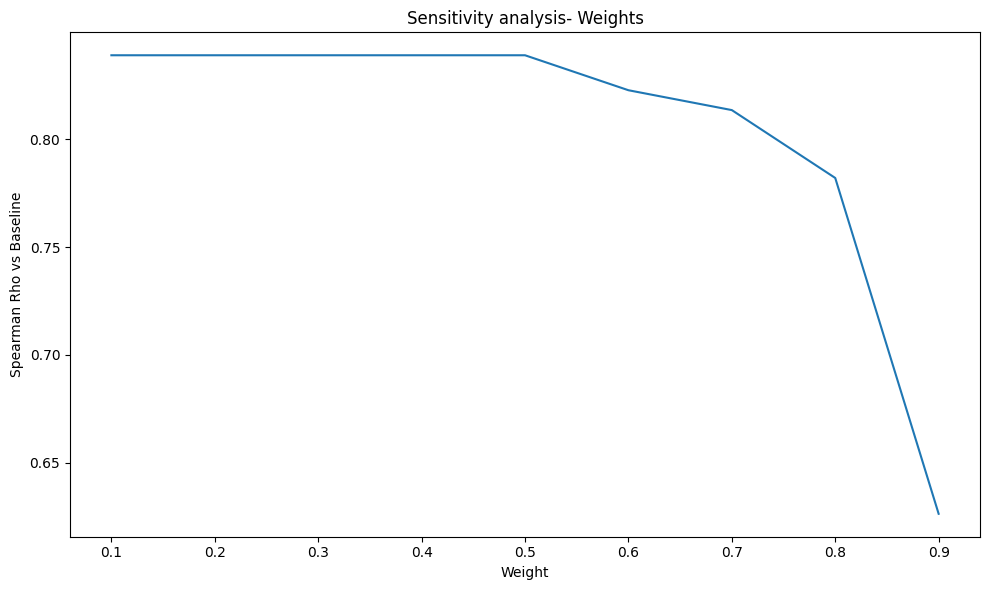

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data = sensitivity,
    x = 'w_skill',
    y = "spearman_rho_vs_baseline"
)

plt.xlabel('Weight')
plt.ylabel('Spearman Rho vs Baseline')
plt.title('Sensitivity analysis- Weights')

plt.tight_layout()

### Suitability

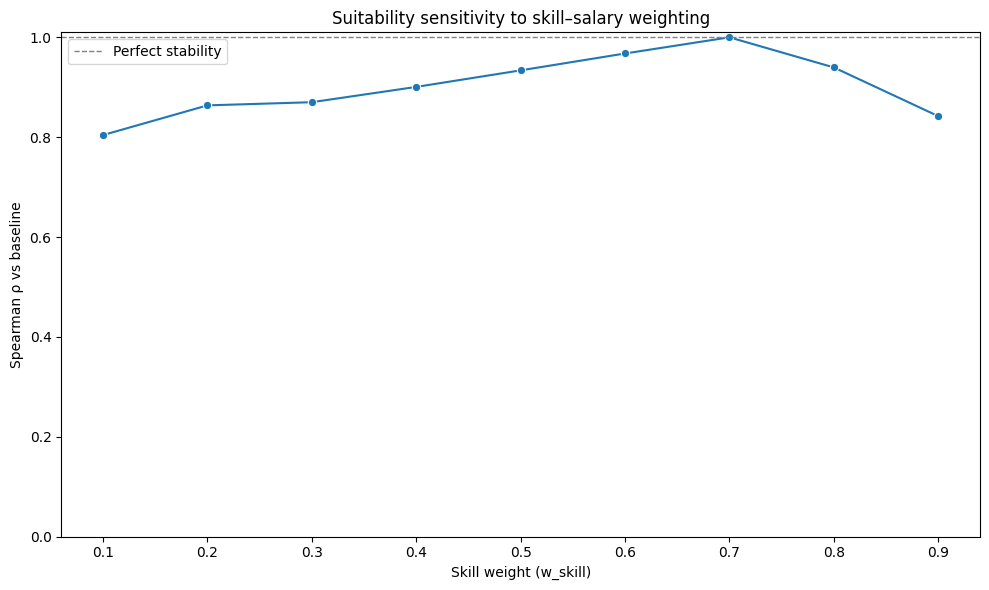

In [14]:


from src.job_intel.features.suitability_sensitivity import (
    compute_suitability_sensitivity
)

# --- run sensitivity ---
suitability_sensitivity = compute_suitability_sensitivity(candidates_df)

# --- plot ---
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=suitability_sensitivity,
    x="w_skill",
    y="spearman_rho_vs_baseline",
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Perfect stability"
)

plt.xlabel("Skill weight (w_skill)")
plt.ylabel("Spearman ρ vs baseline")
plt.title("Suitability sensitivity to skill–salary weighting")

plt.ylim(0, 1.01)
plt.legend()
plt.tight_layout()

# == End of Notebook ==